In [1]:
import pandas as pd
import os

In [4]:
os.chdir("../")

In [9]:
CURR_DIR = os.getcwd()
# print(CURR_DIR)
PARQUET_PATH = os.path.join(CURR_DIR,"artifacts","runs","2026-05-12_204240","decisions.parquet")
# print(PARQUET_PATH) 

In [10]:
df = pd.read_parquet(PARQUET_PATH)
df.head()

,crop_id,source_path,kept,rejected_at_stage,total_elapsed_ms,quality_passed,quality_reason,quality_elapsed_ms,quality_width,quality_height,...,ad_filter_passed,ad_filter_reason,ad_filter_elapsed_ms,ad_filter_best_real_score,ad_filter_best_ad_score,ad_filter_margin,ad_filter_best_real_idx,ad_filter_best_ad_idx,pose_n_torso_visible,pose_n_leg_visible
0,crop (1),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,False,face,1033.4963,True,ok,7.7654,211.0,416.0,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,crop (10),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,False,quality,5.3372,False,brightness: 9.4 < 15.0,1.4236,283.0,719.0,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,crop (100),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,False,person_detection,63.4082,True,ok,0.5561,111.0,849.0,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,crop (1000),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,False,pose,87.3820,True,ok,1.0288,198.0,696.0,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,crop (1001),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,False,person_detection,71.7528,True,ok,1.5640,220.0,641.0,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.columns

Index(['crop_id', 'source_path', 'kept', 'rejected_at_stage',
       'total_elapsed_ms', 'quality_passed', 'quality_reason',
       'quality_elapsed_ms', 'quality_width', 'quality_height',
       'quality_aspect', 'quality_brightness', 'quality_blur_variance',
       'person_detection_passed', 'person_detection_reason',
       'person_detection_elapsed_ms', 'person_detection_n_detections_raw',
       'person_detection_n_detections_valid',
       'person_detection_top_confidence',
       'person_detection_top_bbox_area_ratio', 'pose_passed', 'pose_reason',
       'pose_elapsed_ms', 'pose_n_persons_detected',
       'pose_n_visible_keypoints', 'pose_n_head_visible',
       'pose_n_shoulder_visible', 'pose_n_hip_visible', 'pose_n_knee_visible',
       'face_passed', 'face_reason', 'face_elapsed_ms', 'face_n_faces',
       'face_top_face_confidence', 'face_top_face_area_ratio',
       'face_all_landmarks_in_bbox', 'age_passed', 'age_reason',
       'age_elapsed_ms', 'age_predicted_age', 'a

In [14]:
fails_df = df[df['kept'] == False]

In [15]:
fails_df['rejected_at_stage'].value_counts()

rejected_at_stage
person_detection    323
quality             217
pose                199
face                109
ad_filter            25
age                  11
Name: count, dtype: int64

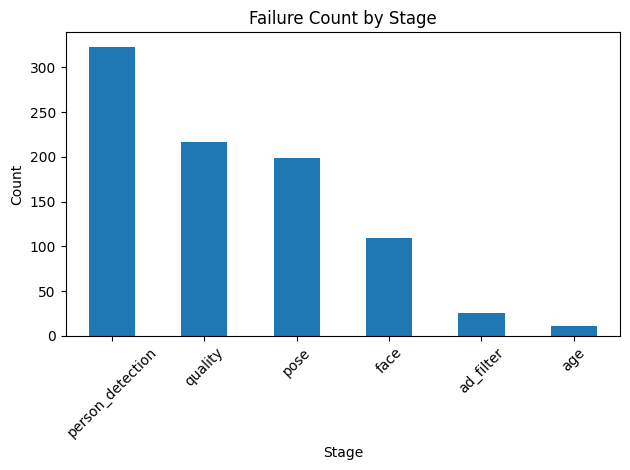

In [17]:
import matplotlib.pyplot as plt

stage_counts = fails_df["rejected_at_stage"].value_counts()

stage_counts.plot(kind="bar")

plt.title("Failure Count by Stage")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

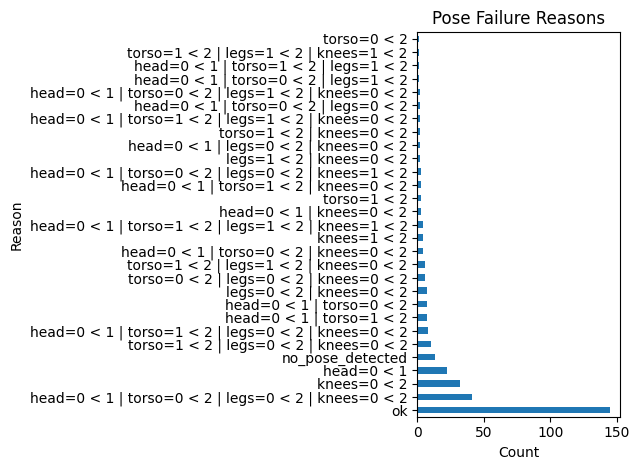

In [19]:
pose_counts = fails_df["pose_reason"].value_counts()

pose_counts.plot(kind="barh")

plt.title("Pose Failure Reasons")
plt.xlabel("Count")
plt.ylabel("Reason")
plt.tight_layout()
plt.show()

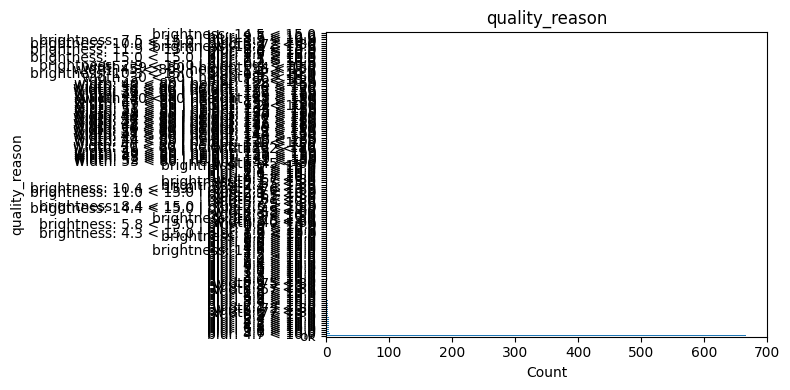

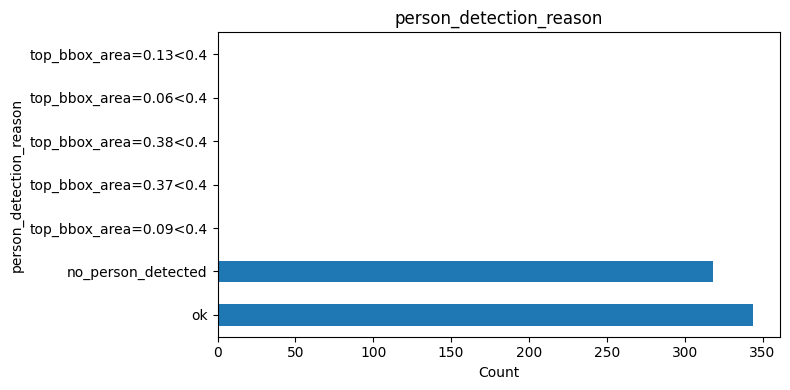

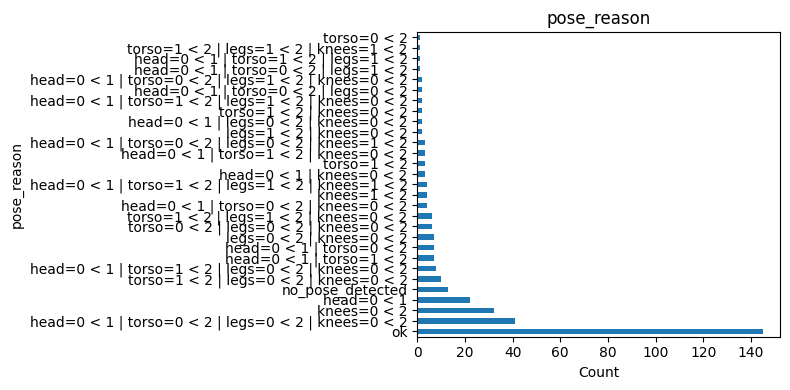

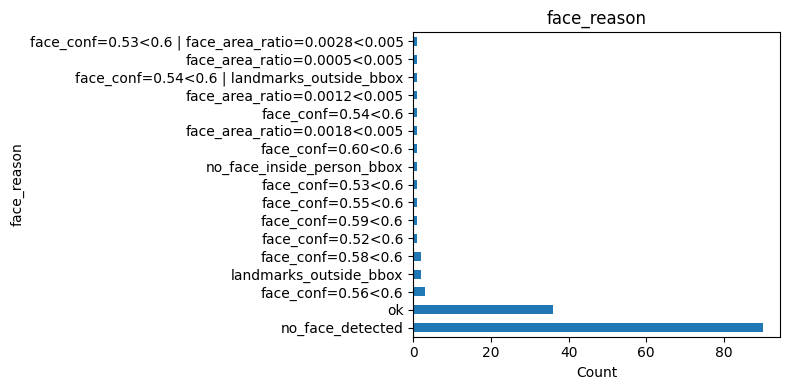

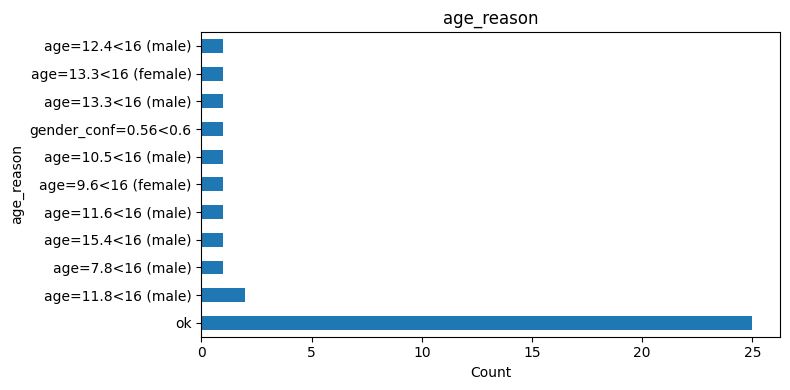

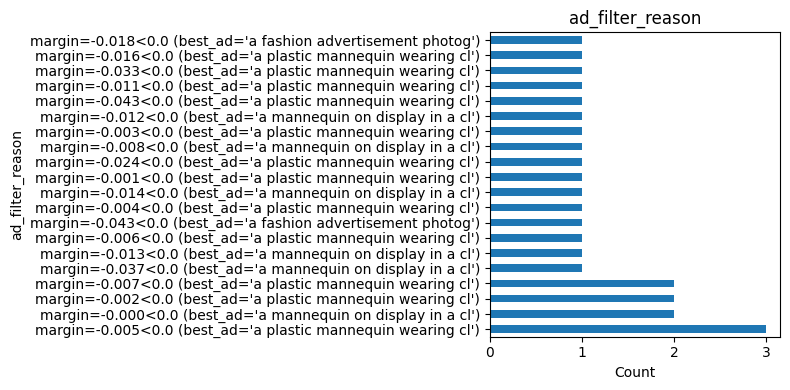

In [21]:
reason_cols = [
    "quality_reason",
    "person_detection_reason",
    "pose_reason",
    "face_reason",
    "age_reason",
    "ad_filter_reason"
]

for col in reason_cols:
    counts = fails_df[col].value_counts()

    if len(counts) > 0:
        plt.figure(figsize=(8,4))
        counts.plot(kind="barh")

        plt.title(col)
        plt.xlabel("Count")
        plt.tight_layout()
        plt.show()

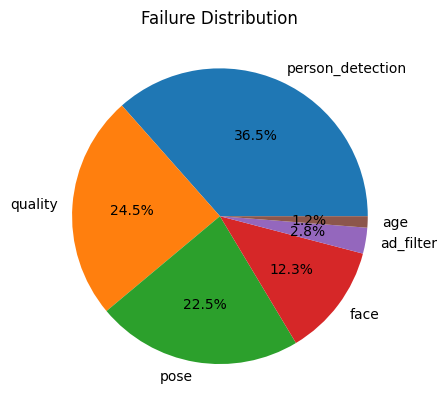

In [22]:
stage_counts.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Failure Distribution")
plt.show()